Import Necessary Packages

In [28]:
import os
import warnings
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, LeakyReLU, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

Load Data

In [29]:
train_path = r"C:\DL Projects\CNN_Project\Training"
test_path = r"C:\DL Projects\CNN_Project\Testing"
categories = ['Not_Smoking', 'Smoking']

X_train, y_train, X_test, y_test = [], [], [], []
def load_data(base_path, data_list, label_list):
    for category in categories:
        folder_path = os.path.join(base_path, category)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = imread(img_path)
                img_resized = resize(img, (150, 150, 3))
                data_list.append(img_resized)
                label_list.append(categories.index(category))
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
        print(f"Loaded category: {category}")

load_data(train_path, X_train, y_train)
load_data(test_path, X_test, y_test)


Loaded category: Not_Smoking
Loaded category: Smoking
Loaded category: Not_Smoking
Loaded category: Smoking


Convert to NumPy arrays and normalize

In [30]:
X_train, X_test = np.array(X_train) , np.array(X_test) 
y_train, y_test = np.array(y_train), np.array(y_test)

Shuffle the data

In [31]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

Model Architecture

In [32]:
model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', input_shape=(150, 150, 3)))
BatchNormalization()
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same'))
BatchNormalization()
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), padding='same'))
BatchNormalization()
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))


model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax')) 




In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,786 (495.26 KB)

 Trainable params: 126,786 (495.26 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [34]:
optimizer = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


 Data Augmentation

In [35]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)


Early Stopping

In [36]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Train the Model

In [37]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=25,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.5568 - loss: 0.6617 - val_accuracy: 0.6339 - val_loss: 0.6142
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 293ms/step - accuracy: 0.6817 - loss: 0.6041 - val_accuracy: 0.7321 - val_loss: 0.5965
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 276ms/step - accuracy: 0.7319 - loss: 0.5683 - val_accuracy: 0.7321 - val_loss: 0.5705
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 373ms/step - accuracy: 0.6796 - loss: 0.6065 - val_accuracy: 0.7321 - val_loss: 0.5510
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 281ms/step - accuracy: 0.7187 - loss: 0.5743 - val_accuracy: 0.7009 - val_loss: 0.5521
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 288ms/step - accuracy: 0.6821 - loss: 0.5983 - val_accuracy: 0.7500 - val_loss: 0.5638
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 417ms/step - accuracy: 0.7264 - loss: 0.5518 - val_accuracy: 0.7411 - val_loss: 0.5510
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step - accuracy: 0.6763 - loss: 0.5816 - val_accu

Evaluate the model

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.7389 - loss: 0.5454

✅ Test Accuracy: 74.11%


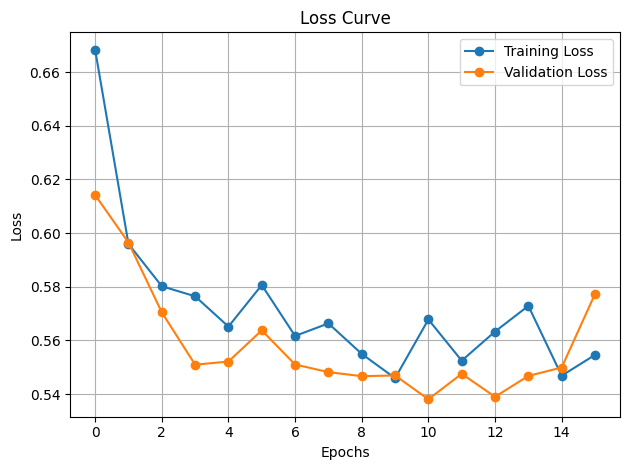

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='Training Loss',marker='o')
plt.plot(history.history['val_loss'],label='Validation Loss',marker='o')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Inference: Both Training loss and Validation loss decrease overall, meaning the model is learning and improving, though there are some small fluctuations. A lower loss value means better performance.

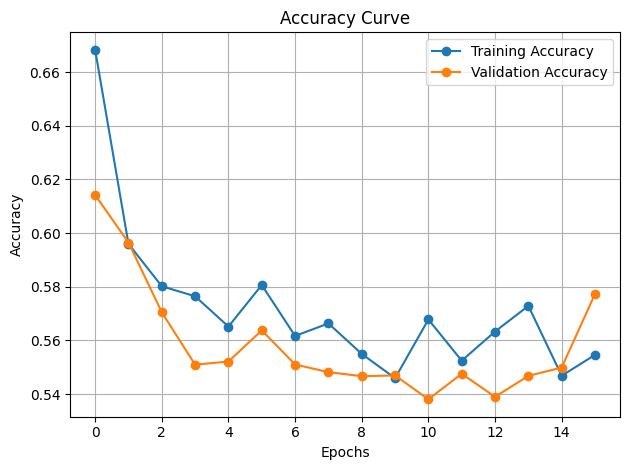

In [40]:
plt.plot(history.history['loss'],label='Training Accuracy',marker='o')
plt.plot(history.history['val_loss'],label='Validation Accuracy',marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Inference: The accuracy curve shows a declining trend, which might indicate learning issues.


Classification Report & Confusion Matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step

Classification Report:
               precision    recall  f1-score   support

 Not_Smoking       0.72      0.78      0.75       112
     Smoking       0.76      0.71      0.73       112

    accuracy                           0.74       224
   macro avg       0.74      0.74      0.74       224
weighted avg       0.74      0.74      0.74       224



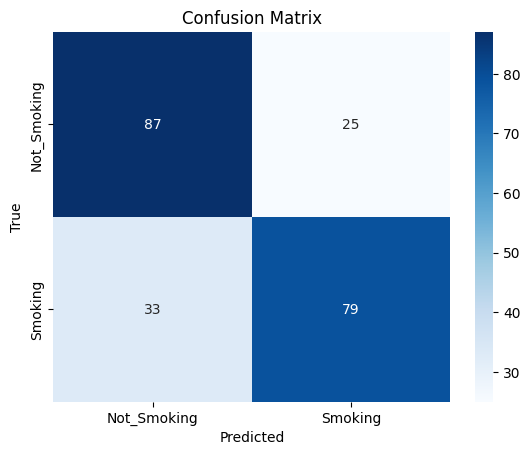

In [41]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=categories))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=categories, yticklabels=categories, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Save the model

In [45]:
model.save("smoking_detection_model.h5")